# End-to-end Stellar Spectra Simulations

### Imports

In [18]:
# basic
from copy import deepcopy
from pathlib import Path
from typing import Optional, Literal
import logging
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.io import fits
from astropy.table import Table
from scipy.ndimage import median_filter

# zs_scopesim_tools convenience routines
import zs_scopesim_tools.helpers
from zs_scopesim_tools.helpers import (disable_scopesim_top_level_catch, warning_prevent_sync_alt_ra_dec,
                                       ignore_warnings, set_scopesim_log_level, make_local_output_dir, configure_irdb_path, timed, list_effects, simulate, save_zshooter_readout, subtract_hduls)
# scopesim and scopesim source creation related
import scopesim as sim
import scopesim_templates as sim_tp
from scopesim.source.source import Source
from scopesim.source import source_templates
from zs_scopesim_tools.sources import lamp_flat, transient, kilonova_spectra
from zs_scopesim_tools.plots import PlotScene, plot_readout_overview
from synphot.units import convert_flux, FLAM

# DRP
from zsdrp.ZSHOOTER import ZSHOOTER
import zsdrp.pipe, zsdrp.steps


configure_irdb_path()  # REQUIRED the first time after installation, sets local IRDB directory path in ScopeSim
set_scopesim_log_level("warning")  # set ScopeSim log toggles
disable_scopesim_top_level_catch()
ignore_warnings()
logging.disable(logging.WARNING)

### Setup

Set up OUTPUT directory, remember to change it if running different simulations from same notebook to prevent accidental overrides.

In [2]:
OUTDIR = make_local_output_dir(dirname="02_Stellar/")

Load the latest ZShooter instrument model configurations (from local `IRDB/ZShooter_v2`).

In [3]:
zs_config = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])

`list_effects()` is a helper to make a dataframe of all the optical effects in the model with some basic information about each.

In [4]:
df = list_effects(zs_config)
# df

##### Helper function to update observing parameters and run simulation in one-shot

Example usage:
```python
hdul, train = update_params_and_observe(object_name = "object_name_identifier", # string name
                                        imagetype = "SCIENCE", # one of BIAS, DOMEFLAT, ARCS, SCIENCE
                                        source = Source, # scopesim Source object instance
                                        exptimes = [300, 300, 300, 100, 100, 100], # list of 6 numbers, one per channel
                                        output_dir = "/path/to/output/directory",
                                        disable_effects = ["name_of_effect_to_disable", "..."],
                                        disable_backgrounds = ["sky_lines"], # one of sky, sky_lines, sky_continuum
                                        airmass = 1.3,
                                        seeing = 0.7,
                                        brightness = "grey", # one of bright, grey, dark
                                        vis_slit = 0.7, # one of 1.25, 0.70, 0.57, 0.50, 0.42, 0.37, 0.33
                                        nir_slit = 0.7, # one of 1.25, 0.70, 0.57, 0.50, 0.42, 0.37, 0.33
                                        pixel_scale = None, # uses instrument default
                                        pupil_angle = None, # uses instrument default
                                        ao_on = False, # AO effect ON/OFF
                                        diffuse_emissivity_on = False)
```
Returns the raw detector HDULists and the OpticalTrain object.

In [19]:
@timed
def update_params_and_observe(object_name: str,
                              imagetype: str,
                              source: Source,
                              exptimes: Optional[list | float] = None,
                              ndit: int = 1,
                              output_dir: Optional[str | Path]=None,
                              *,
                              disable_effects: Optional[list[str]]=None,
                              disable_backgrounds: Optional[list[Literal["sky", "sky_continuum", "sky_lines"]]]=None,
                              airmass: Optional[float]=None,
                              seeing: Optional[float]=None,
                              brightness: Optional[Literal["bright", "grey", "dark"]]=None,
                              vis_slit: Optional[float]=None,
                              nir_slit: Optional[float]=None,
                              pixel_scale: Optional[float]=None,
                              pupil_angle: Optional[float]=None,
                              ao_on: bool=False,
                              diffuse_emissivity_on: bool=False,
                              params: Optional[dict]=None
                              ) -> tuple[list, sim.optics.OpticalTrain]:
    """
    :param object_name: Name of the Source object
    :param imagetype: IMAGETYPE keyword (BIAS, DOMEFLAT, ARCS, SKY, SCIENCE)
    :param source: Source instance
    :param exptimes: List of exposure times in channel order (blue, green, red, yj, h, k) in seconds, or single value.
                If None, it is set to 0.0.
    :param ndit: number of exposures
    :param output_dir: Directory to save observed data in, FITS files are saved with {object_name}_{CHANNEL}.fits names
                        where CHANNEL is in [BLUE, GREEN, RED, YJ, H, K] (upper case)
    :param disable_effects: List of effect names to disable
    :param disable_backgrounds: List of background names to disable, options are "sky", "sky_continuum", or "sky_lines".
    :param airmass: Airmass
    :param seeing: Seeing (natural)
    :param brightness: Brightness of sky ("bright", "grey", or "dark")
    :param vis_slit: Slit width for Visible channel
    :param nir_slit: Slit width for NIR channel
    :param pixel_scale: Instrument pixel scale
    :param pupil_angle: Instrument pupil angle
    :param ao_on: True for AO correction on, defaults to False
    :param diffuse_emissivity_on: True for diffuse emissivity effect on, defaults to False
    :param params: Dict of any other UserCommands alias keys and values to set

    :return: tuple(HDUList, OpticalTrain)
    """
    if imagetype not in ["BIAS", "DOMEFLAT", "ARCS", "SKY", "SCIENCE"]:
        raise ValueError(f"Imagetype {imagetype} is incorrect! Choose from BIAS, DOMEFLAT, ARCS, SCIENCE.")
    # load ZShooter_v2 irdb model config
    config = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
    # update with passed params
    config["!OBS.airmass"] = airmass if airmass else config["!OBS.airmass"]
    config["!OBS.seeing"] = seeing if seeing else config["!OBS.seeing"]
    config["!OBS.brightness"] = brightness if brightness else config["!OBS.brightness"]
    config["!OBS.pupil_angle"] = pupil_angle if pupil_angle else config["!OBS.pupil_angle"]
    config["!INST.vis_curr_slit"] = vis_slit if vis_slit else config["!INST.vis_curr_slit"]
    config["!INST.nir_curr_slit"] = nir_slit if nir_slit else config["!INST.nir_curr_slit"]
    config["!INST.pixel_scale"] = pixel_scale if pixel_scale else config["!INST.pixel_scale"]
    config["!INST.include_diffuse_emissivity"] = diffuse_emissivity_on
    config["!ATMO.ao_enabled"] = ao_on

    dits = [0.]*6 if exptimes is None else [exptimes]*6 if not isinstance(exptimes, list) else exptimes
    for dit, expkey in zip(dits, ['blue', 'green', 'red', 'yj', 'h', 'k']):
        config[f"!OBS.dit_{expkey}"] = dit
        config[f"!OBS.ndit_{expkey}"] = 1.

    if params is not None and isinstance(params, dict):
        params = {key:val for key, val in params.items() if key in config}
        # USE THIS TO UPDATE THE CONFIG WITH NEW PROPERTIES, IT IS NOT A NORMAL DICT
        config.update_alias(config, params)
    # make sure airmass, ra, dec are in sync if all are provided
    warning_prevent_sync_alt_ra_dec(config)

    # call simulate(), it inits optical train, runs observe() and readout()
    print(f'Simulating {object_name}')
    n_hduls = []
    for i in range(ndit):
        zs, hdul = simulate(config, source=source, disable_effects=disable_effects, disable_backgrounds=disable_backgrounds, hide_progress_bars=True)
        # check desired counts
        print(f'Max counts per channel: {[int(np.max(hdu[1].data)) for hdu in hdul]}')
        # save the simulated readout to fits files
        if output_dir is not None:
            _ = save_zshooter_readout(hdul, output_dir=output_dir, object_name=object_name,
                                          imagetype=imagetype.upper(), ndit=i, cmds=config, train=zs)
            print(f"Saved readout #{i}/{ndit} in {output_dir}")
        n_hduls.append(hdul)

    return n_hduls, zs


## Create Stellar Sources

Spectra provided by Kareem El-Badry.

In [20]:
from synphot import SourceSpectrum
from astropy.table import Table

spectra_path = Path("source_data/Kareem_stellar/spectra/").resolve()
spectrum_files = sorted(spectra_path.glob('*.fits'))

sources = dict()
for specfile in spectrum_files:
    temp = Table.read(specfile, format='fits')
    print(str(specfile.stem), np.max(temp['FLUX']))
    basename = str(specfile.stem).split('.')[0]
    sources[basename] = sim_tp.misc.point_source(sed=SourceSpectrum.from_file(str(specfile)))

bstar2006_T20000_logg4p50_solar_G15_R100000 1.63220894511923e-14
bstar2006_T20000_logg4p50_solar_G17_R100000 2.586876845793603e-15
bstar2006_T20000_logg4p50_solar_G19_R100000 4.099923502633558e-16
bstar2006_T20000_logg4p50_solar_G21_R100000 6.49794084893525e-17
ostar2002_T55000_logg4p50_solar_G15_R100000 3.1574066163573267e-14
ostar2002_T55000_logg4p50_solar_G17_R100000 5.004152252096405e-15
ostar2002_T55000_logg4p50_solar_G19_R100000 7.931046838386541e-16
ostar2002_T55000_logg4p50_solar_G21_R100000 1.2569862143249065e-16
phoenix_T05500_logg4p50_solar_G15_R100000 4.0521103853088385e-15
phoenix_T05500_logg4p50_solar_G17_R100000 6.422162164776957e-16
phoenix_T05500_logg4p50_solar_G19_R100000 1.0178441095836326e-16
phoenix_T05500_logg4p50_solar_G21_R100000 1.613174200265743e-17


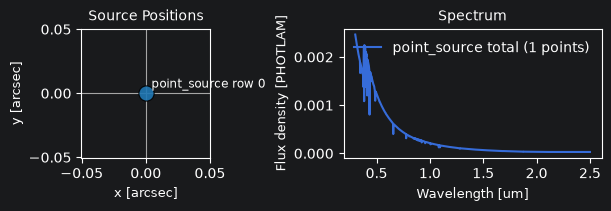

In [21]:
_ = PlotScene().from_source(sources["bstar2006_T20000_logg4p50_solar_G15_R100000"])

### Simulating cal+science

Set your observing parameters in cell below.

If you change any instrument related parameters for a science object simulation (like vis_slit, nir_slit, ao_on or diffuse_emissivity_on)
 - **<font color='red'>Make sure to simulate a complementary set of cals with the same parameters!</font>**
 - **<font color='red'>Make sure you CHANGE the output_dir so that your data doesn't get overwritten!</font>**

#### Configuration 1: 0.3" slit width

In [34]:
airmass = 1.3
seeing = 0.7
brightness = "grey"
vis_slit = 0.30
nir_slit = 0.30
ao_on = False
diffuse_emissivity_on = False
params = {"!SIM.spectral.spectral_bin_width": 0.000005}
# creating a sub-directory in OUTDIR for this run config, naming it based on config params
output_dir = OUTDIR / f"slit_{vis_slit}"
output_dir.mkdir(parents=True, exist_ok=True)

overwrite_cals = True  # set True to redo cals
plot = False  # Set True for plotting

args = {'airmass':airmass, 'seeing':seeing, 'brightness':brightness, 'vis_slit':vis_slit, 'nir_slit':nir_slit,
        'ao_on': ao_on, 'diffuse_emissivity_on': diffuse_emissivity_on, 'params':params}

Cell below simulates bias, domeflat, arcs and a standard star

In [11]:
# for cals
disable_effects_cals = ["atmo_transmission", "continuum_emission", "airglow_and_interline_continuum",
                        "seeing_psf", "adc_residuals"]
if overwrite_cals or len(sorted(output_dir.glob("*bias*")))!=6:
    # bias
    bias_hdul, _ = update_params_and_observe(object_name="bias", imagetype="BIAS", source=None, exptimes=0,
                                             output_dir=output_dir, disable_effects=disable_effects_cals, **args)
    # arcs
    LAMP = lamp_flat()
    arcs_hdul, _ = update_params_and_observe(object_name="arcs", imagetype="ARCS", source=LAMP,
                                             exptimes=[40, 40, 3, 3, 20, 10], output_dir=output_dir,
                                             disable_effects=disable_effects_cals, **args)
    # domeflat
    DOMEFLAT = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=8*u.ABmag, filter_curve='V', extend=60)
    domeflat_hdul, _ = update_params_and_observe(object_name="domeflat", imagetype="DOMEFLAT", source=DOMEFLAT,
                                                 exptimes=[120, 10, 3, 3, 3, 3], output_dir=output_dir,
                                                 disable_effects=disable_effects_cals, **args)
    # standard star
    STANDARD = sim_tp.misc.point_source(sed=source_templates.ab_spectrum(mag=16))
    std_hdul, _ = update_params_and_observe(object_name="standard", imagetype="SCIENCE", source=STANDARD,
                                            exptimes=100, disable_backgrounds=["sky"], output_dir=output_dir, **args)
    if plot:
        _, _ = plot_readout_overview(bias_hdul,
                                        titles=[f"bias {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = PlotScene().from_source(LAMP)
        _, _ = plot_readout_overview(arcs_hdul,
                                        titles=[f"arcs {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = plot_readout_overview(domeflat_hdul,
                                        titles=[f"domeflat {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = plot_readout_overview(std_hdul,
                                        titles=[f"standard {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])

Simulating bias
Max counts per channel: [1040, 1040, 1040, 2, 2, 2]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.3
update_params_and_observe(bias): 81.4 s
Simulating arcs
Max counts per channel: [21500, 31450, 32908, 30867, 33508, 37494]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.3
update_params_and_observe(arcs): 38.5 s
Simulating domeflat
Max counts per channel: [20683, 21528, 25416, 34528, 38611, 36363]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.3
update_params_and_observe(domeflat): 37.5 s
Simulating standard
Max counts per channel: [1099, 1124, 1141, 109, 118, 457]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.3
update_params_and_observe(standard): 58.7 s


Simulating each spectrum at 600 s, 1800 s, 3600 s of total exptime as 300x2, 900x2, 1800x2. A sky frame is simulated per exptime, and subtracted from the source HDUs, both source and source-sky HDUs are saved.

In [12]:
from zs_scopesim_tools.helpers import subtract_hduls

for exptime in [300, 900, 1800]:  # 2 ndit each so total exptime is 600, 1800, 3600
    #sky
    sky_hduls, _ = update_params_and_observe(object_name=f"sky_{exptime}", imagetype="SKY", source=None, exptimes=exptime, output_dir=output_dir, **args)

    for objname, source in sources.items():
        hduls, _ = update_params_and_observe(object_name=f"{objname}_{exptime}", imagetype="SCIENCE", source=source, exptimes=exptime, ndit=2, output_dir=output_dir, **args)

        for i, hdul in enumerate(hduls):
            sub_hdul = subtract_hduls(hdul, sky_hduls[0])
            _ = save_zshooter_readout(sub_hdul, output_dir=output_dir, object_name=f"{objname}_{exptime}_SUB",
                                      imagetype="SCIENCE", ndit=i, extra_headers={"SUBTRACTED": True})


Simulating sky_300
Max counts per channel: [1050, 1949, 4673, 23802, 124809, 44699]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.3
update_params_and_observe(sky_300): 61.0 s
Simulating bstar2006_T20000_logg4p50_solar_G15_R100000_300
Max counts per channel: [1530, 2198, 4802, 23702, 125403, 44814]
Saved readout #0/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.3
Max counts per channel: [1540, 2181, 4768, 23618, 125035, 44546]
Saved readout #1/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.3
update_params_and_observe(bstar2006_T20000_logg4p50_solar_G15_R100000_300): 140.3 s
Simulating bstar2006_T20000_logg4p50_solar_G17_R100000_300
Max counts per channel: [1137, 1959, 4681, 23702, 124756, 44550]
Saved readout #0/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.3
Max counts per channel: [1134, 1952, 4654, 23588, 124789, 44356]
Saved readout #1/2 in /Users/ya

Reduce

In [35]:
REDUCED_DIR = output_dir / "reduced"
REDUCED_DIR.mkdir(exist_ok=True)

In [ ]:
zspy = ZSHOOTER()
files = {}
for chan in zspy.config.channels:
    stepnames = ['bias','flat','wavecal_master','science']
    file_groups = zspy.sort_files(str(output_dir), target='', night='', channel=chan, steps=stepnames)
    _, fls = file_groups[0]
    files[chan] = {name: fls[name] for name in stepnames}

results = zsdrp.pipe.run_reduction(files, channels=None, output_dir=REDUCED_DIR, disable_steps=['mask'], print_params=False, disable_all_plots=True, reuse_cals=False)

reference = source_templates.ab_spectrum(mag=16)
reference_wave = reference.waveset
reference_flux = convert_flux(reference_wave, reference(reference_wave), "FLAM")

final_spectra = zsdrp.pipe.run_flux_calibration_and_stitch(results, reference_wave=reference_wave, reference_flux=reference_flux, plot=False, output_dir=REDUCED_DIR)
del results, final_spectra

bstar2006_T20000_logg4p50_solar_G15_R100000_300_SUB: mean SNR = 43.46, median SNR = 42.85
bstar2006_T20000_logg4p50_solar_G15_R100000_900_SUB: mean SNR = 71.41, median SNR = 70.46
bstar2006_T20000_logg4p50_solar_G15_R100000_1800_SUB: mean SNR = 95.24, median SNR = 93.78


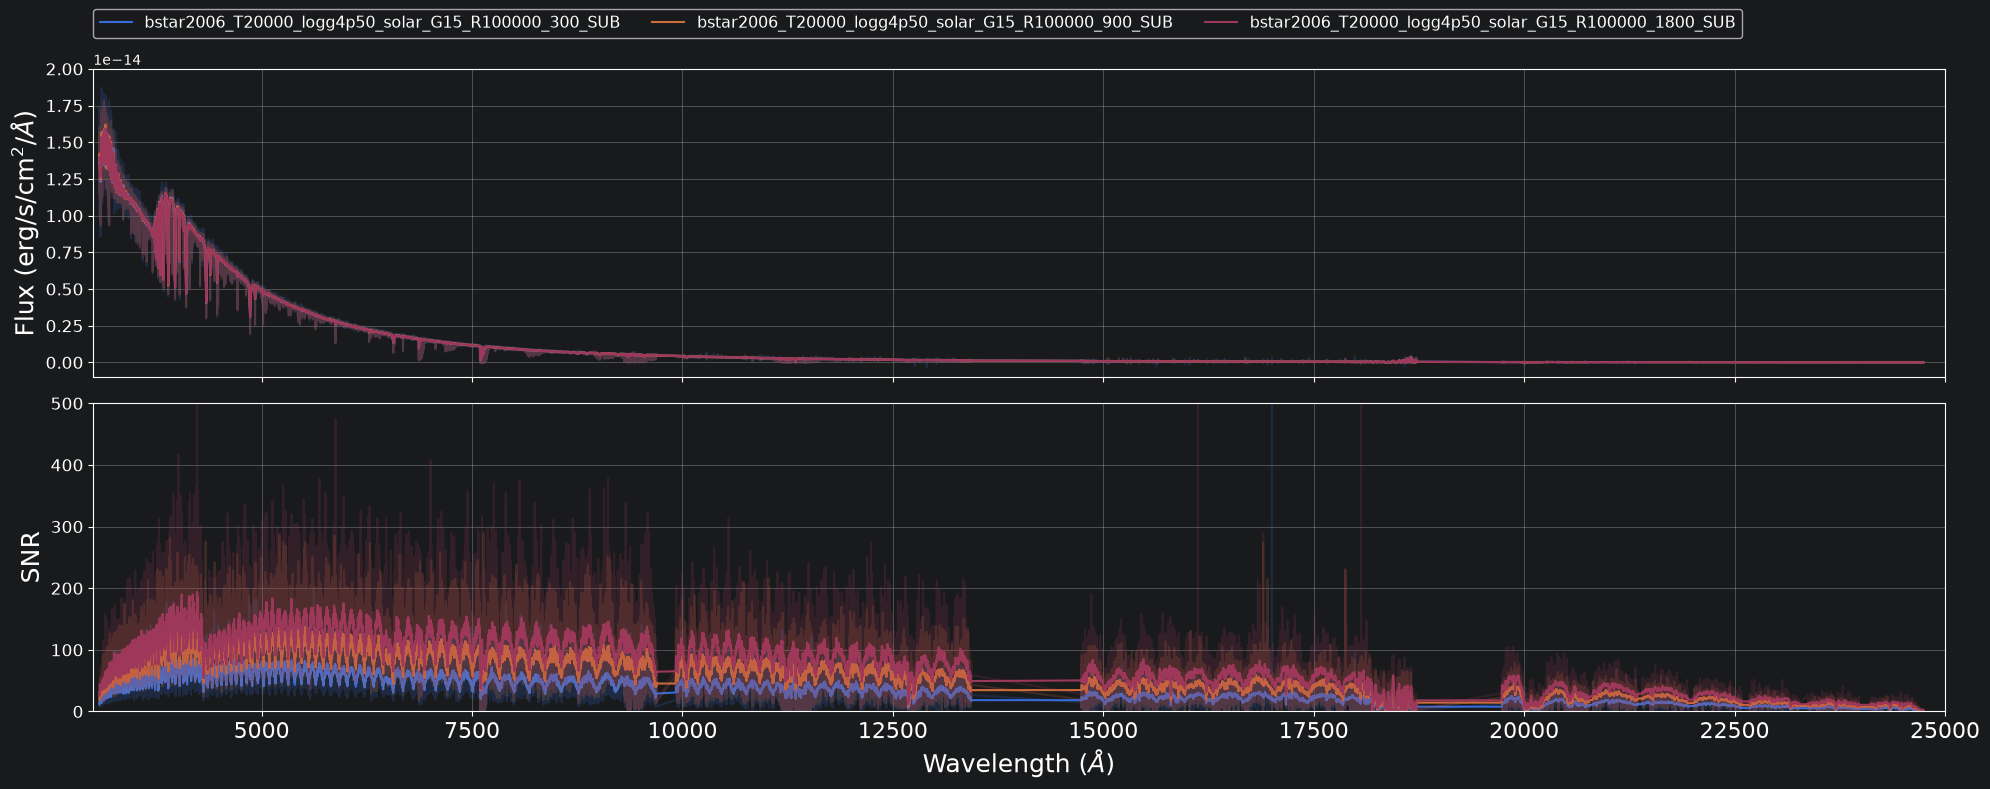

In [36]:
fig, ax = plt.subplots(2,1, figsize=(20,8), tight_layout=True, sharex=True)
ax[0].grid(True)
ax[1].grid(True)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='x', labelsize=16)
ax[0].set_ylabel('Flux (erg/s/cm$^2/\AA$)', fontsize=18)
ax[1].set_ylabel('SNR', fontsize=18)
ax[1].set_xlabel('Wavelength ($\AA$)', fontsize=18)

obj = list(sources.keys())[0]
colors = ['cornflowerblue','green','orangered']
for i,exptime in enumerate([300, 900, 1800]):
    objname = f"{obj}_{exptime}_SUB"
    flname = sorted(REDUCED_DIR.glob(f'*{objname.upper()}*stitched.txt'))[0]
    with open(flname, 'r', encoding='utf-8') as f:
        tbl = pd.read_csv(f, sep='\t', comment='# ', engine='python')
        wave = tbl['wavelength']
        spec = tbl['flux']
        sig = tbl['eflux']
        snr = spec/sig
        good = np.isfinite(snr)
        print(f"{objname}: mean SNR = {np.mean(snr[good]):.2f}, "
              f"median SNR = {np.median(snr[good]):.2f}")

        ax[0].plot(wave, spec, alpha=0.2, color=f"C{i}")
        ax[0].plot(wave, median_filter(spec, 51), label=objname, color=f"C{i}")
        ax[1].plot(wave, snr, alpha=0.2, color=f"C{i}")
        ax[1].plot(wave, median_filter(snr , 51), label=objname, color=f"C{i}")

ax[0].set_xlim(3000, 25000)
ax[0].set_ylim(-0.1e-14, 2e-14)
ax[1].set_ylim(0, 500)
ax[0].legend(ncol=3, fontsize=11.5, loc=(0,1.1))

#### Configuration 2: 0.7" slit width

In [8]:
airmass = 1.3
seeing = 0.7
brightness = "grey"
vis_slit = 0.7
nir_slit = 0.7
ao_on = False
diffuse_emissivity_on = False
params = {"!SIM.spectral.spectral_bin_width": 0.00001}
# creating a sub-directory in OUTDIR for this run config, naming it based on config params
output_dir = OUTDIR / f"slit_{vis_slit}"
output_dir.mkdir(parents=True, exist_ok=True)

overwrite_cals = True  # set True to redo cals
plot = False  # Set True for plotting

args = {'airmass':airmass, 'seeing':seeing, 'brightness':brightness, 'vis_slit':vis_slit, 'nir_slit':nir_slit,
        'ao_on': ao_on, 'diffuse_emissivity_on': diffuse_emissivity_on, 'params':params}

In [9]:
# for cals
disable_effects_cals = ["atmo_transmission", "continuum_emission", "airglow_and_interline_continuum",
                        "seeing_psf", "adc_residuals"]
if overwrite_cals or len(sorted(output_dir.glob("*bias*")))!=6:
    # bias
    bias_hdul, _ = update_params_and_observe(object_name="bias", imagetype="BIAS", source=None, exptimes=0,
                                             output_dir=output_dir, disable_effects=disable_effects_cals, **args)
    # arcs
    LAMP = lamp_flat()
    arcs_hdul, _ = update_params_and_observe(object_name="arcs", imagetype="ARCS", source=LAMP,
                                             exptimes=[40, 40, 3, 3, 20, 10], output_dir=output_dir,
                                             disable_effects=disable_effects_cals, **args)
    # domeflat
    DOMEFLAT = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=8*u.ABmag, filter_curve='V', extend=60)
    domeflat_hdul, _ = update_params_and_observe(object_name="domeflat", imagetype="DOMEFLAT", source=DOMEFLAT,
                                                 exptimes=[120, 10, 3, 3, 3, 3], output_dir=output_dir,
                                                 disable_effects=disable_effects_cals, **args)
    # standard star
    STANDARD = sim_tp.misc.point_source(sed=source_templates.ab_spectrum(mag=16))
    std_hdul, _ = update_params_and_observe(object_name="standard", imagetype="SCIENCE", source=STANDARD,
                                            exptimes=100, disable_backgrounds=["sky"], output_dir=output_dir, **args)
    if plot:
        _, _ = plot_readout_overview(bias_hdul,
                                        titles=[f"bias {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = PlotScene().from_source(LAMP)
        _, _ = plot_readout_overview(arcs_hdul,
                                        titles=[f"arcs {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = plot_readout_overview(domeflat_hdul,
                                        titles=[f"domeflat {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = plot_readout_overview(std_hdul,
                                        titles=[f"standard {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])

Simulating bias
Max counts per channel: [1040, 1040, 1040, 2, 2, 2]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.7
update_params_and_observe(bias): 36.3 s
Simulating arcs
Max counts per channel: [24633, 33720, 33317, 31937, 35160, 37847]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.7
update_params_and_observe(arcs): 30.4 s
Simulating domeflat
Max counts per channel: [39835, 41789, 49470, 68743, 76732, 72356]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.7
update_params_and_observe(domeflat): 29.1 s
Simulating standard
Max counts per channel: [1139, 1176, 1203, 180, 203, 826]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.7
update_params_and_observe(standard): 44.3 s


In [10]:
from zs_scopesim_tools.helpers import subtract_hduls

for exptime in [300, 900, 1800]:
    #sky
    sky_hduls, _ = update_params_and_observe(object_name=f"sky_{exptime}", imagetype="SKY", source=None, exptimes=exptime, output_dir=output_dir, **args)

    for objname, source in sources.items():
        hduls, _ = update_params_and_observe(object_name=f"{objname}_{exptime}", imagetype="SCIENCE", source=source, exptimes=exptime, ndit=2, output_dir=output_dir, **args)

        for i, hdul in enumerate(hduls):
            sub_hdul = subtract_hduls(hdul, sky_hduls[0])
            _ = save_zshooter_readout(sub_hdul, output_dir=output_dir, object_name=f"{objname}_{exptime}_SUB",
                                      imagetype="SCIENCE", ndit=i, extra_headers={"SUBTRACTED": True})


Simulating sky_300
Max counts per channel: [1055, 1883, 4754, 25031, 138955, 70704]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.7
update_params_and_observe(sky_300): 51.3 s
Simulating bstar2006_T20000_logg4p50_solar_G15_R100000_300
Max counts per channel: [1904, 2266, 5060, 25200, 139220, 70771]
Saved readout #0/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.7
Max counts per channel: [1907, 2328, 4968, 25377, 139654, 70774]
Saved readout #1/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.7
update_params_and_observe(bstar2006_T20000_logg4p50_solar_G15_R100000_300): 114.4 s
Simulating bstar2006_T20000_logg4p50_solar_G17_R100000_300
Max counts per channel: [1197, 1908, 4772, 25091, 138888, 70181]
Saved readout #0/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/02_Stellar/slit_0.7
Max counts per channel: [1204, 1936, 4741, 25030, 139120, 70536]
Saved readout #1/2 in /Users/ya

 Reduce

In [13]:
# output_dir = OUTDIR / "slit_0.7_v3"
REDUCED_DIR = output_dir / "reduced"
REDUCED_DIR.mkdir(exist_ok=True)

In [14]:
zspy = ZSHOOTER()
files = {}
for chan in zspy.config.channels:
    stepnames = ['bias','flat','wavecal_master','science']
    file_groups = zspy.sort_files(str(output_dir), target='', night='', channel=chan, steps=stepnames)
    _, fls = file_groups[0]
    files[chan] = {name: fls[name] for name in stepnames}

results = zsdrp.pipe.run_reduction(files, channels=None, output_dir=REDUCED_DIR, disable_steps=['mask'], print_params=False, disable_all_plots=True, reuse_cals=False)

reference = source_templates.ab_spectrum(mag=16)
reference_wave = reference.waveset
reference_flux = convert_flux(reference_wave, reference(reference_wave), "FLAM")

final_spectra = zsdrp.pipe.run_flux_calibration_and_stitch(results, reference_wave=reference_wave, reference_flux=reference_flux, plot=False, output_dir=REDUCED_DIR)
del results, final_spectra

100%|██████████| 906/906 [00:00<00:00, 1682.15it/s]


Running reduction for channel BLUE...


Trace: 100%|██████████| 34/34 [00:03<00:00, 10.51it/s]


simple_wavesol: 726/726 lines, channel +0.028 -0.076 x/nx px, rms 0.285 px
Running reduction for channel GREEN...


Trace: 100%|██████████| 30/30 [00:05<00:00,  5.74it/s]


...

simple_wavesol: 168/170 lines, channel +0.002 -0.005 x/nx px, rms 0.021 px
Running reduction for channel H...


Trace: 100%|██████████| 11/11 [00:01<00:00,  8.18it/s]


simple_wavesol: 100/100 lines, channel -0.000 +0.004 x/nx px, rms 0.013 px
Running reduction for channel K...


Trace: 100%|██████████| 8/8 [00:00<00:00, 10.85it/s]


simple_wavesol: 56/56 lines, channel -0.008 +0.003 x/nx px, rms 0.047 px


bstar2006_T20000_logg4p50_solar_G15_R100000_300_SUB: mean SNR = 57.71, median SNR = 57.19
bstar2006_T20000_logg4p50_solar_G15_R100000_900_SUB: mean SNR = 94.65, median SNR = 93.84
bstar2006_T20000_logg4p50_solar_G15_R100000_1800_SUB: mean SNR = 126.17, median SNR = 125.00


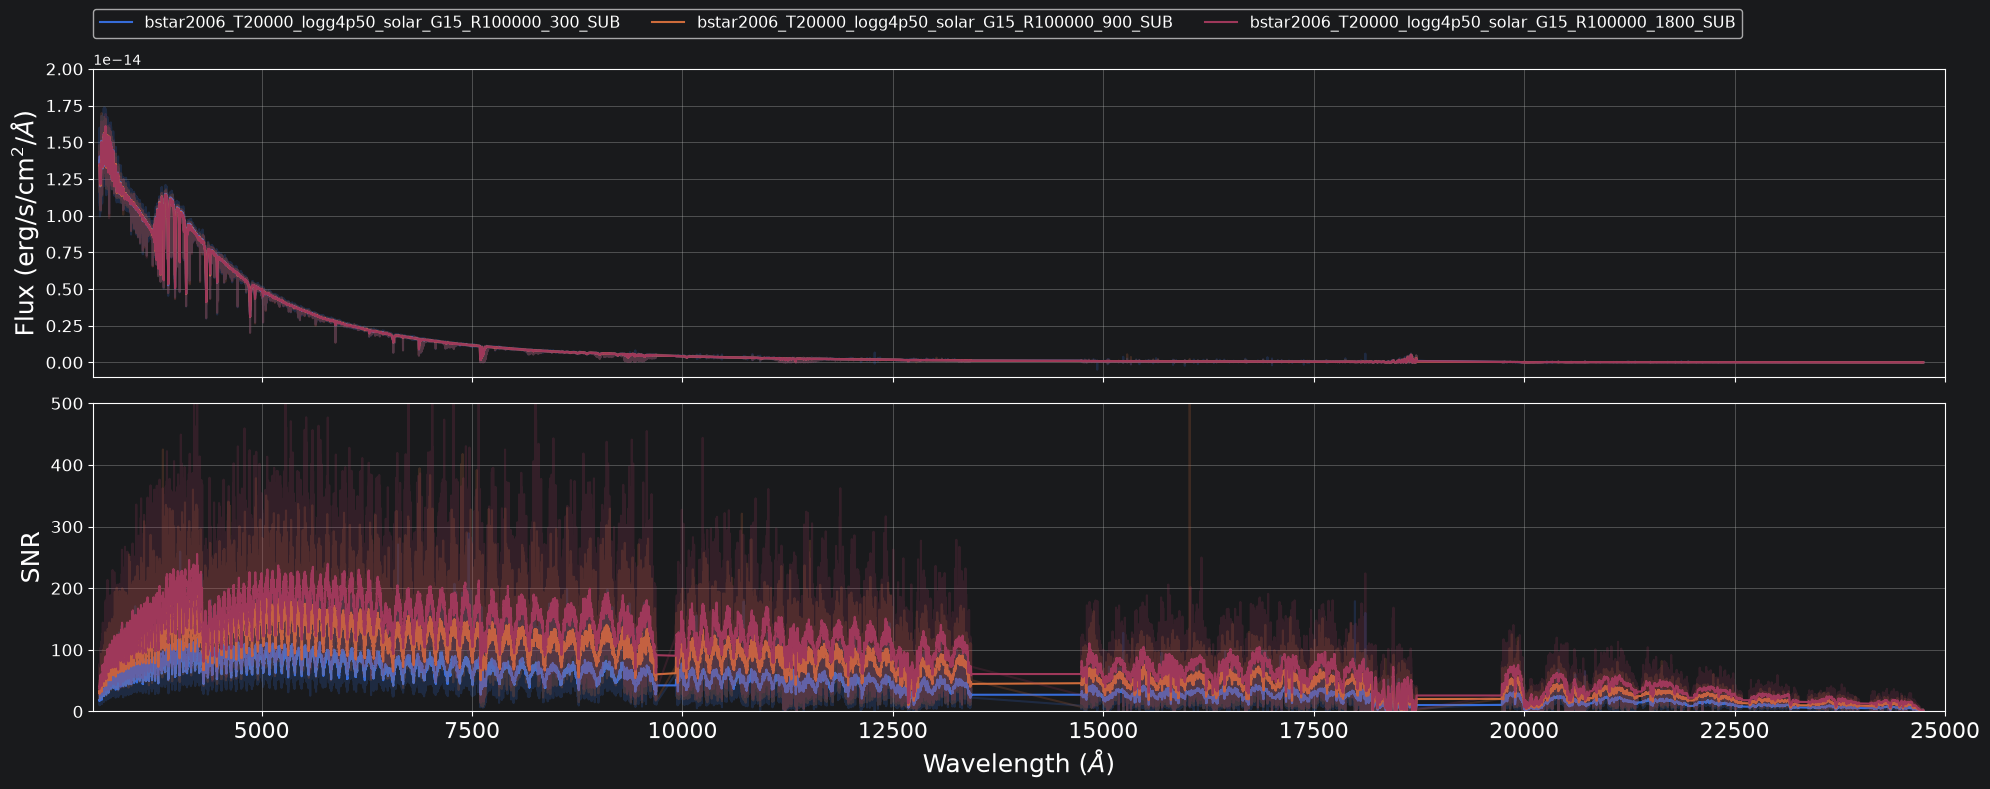

In [16]:
fig, ax = plt.subplots(2,1, figsize=(20,8), tight_layout=True, sharex=True)
ax[0].grid(True)
ax[1].grid(True)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='x', labelsize=16)
ax[0].set_ylabel('Flux (erg/s/cm$^2/\AA$)', fontsize=18)
ax[1].set_ylabel('SNR', fontsize=18)
ax[1].set_xlabel('Wavelength ($\AA$)', fontsize=18)

obj = list(sources.keys())[0]
colors = ['cornflowerblue','green','orangered']
for i,exptime in enumerate([300, 900, 1800]):
    objname = f"{obj}_{exptime}_SUB"
    flname = sorted(REDUCED_DIR.glob(f'*{objname.upper()}_stitched.txt'))[0]
    with open(flname, 'r', encoding='utf-8') as f:
        tbl = pd.read_csv(f, sep='\t', comment='# ', engine='python')
        wave = tbl['wavelength']
        spec = tbl['flux']
        sig = tbl['eflux']
        snr = spec/sig
        good = np.isfinite(snr)
        print(f"{objname}: mean SNR = {np.mean(snr[good]):.2f}, "
              f"median SNR = {np.median(snr[good]):.2f}")

        ax[0].plot(wave, spec, alpha=0.2, color=f"C{i}")
        ax[0].plot(wave, median_filter(spec, 51), label=objname, color=f"C{i}")
        ax[1].plot(wave, snr, alpha=0.2, color=f"C{i}")
        ax[1].plot(wave, median_filter(snr , 51), label=objname, color=f"C{i}")

ax[0].set_xlim(3000, 25000)
ax[0].set_ylim(-0.1e-14, 2e-14)
ax[1].set_ylim(0, 500)
ax[0].legend(ncol=3, fontsize=11.5, loc=(0,1.1))

#### Visualizing stitching

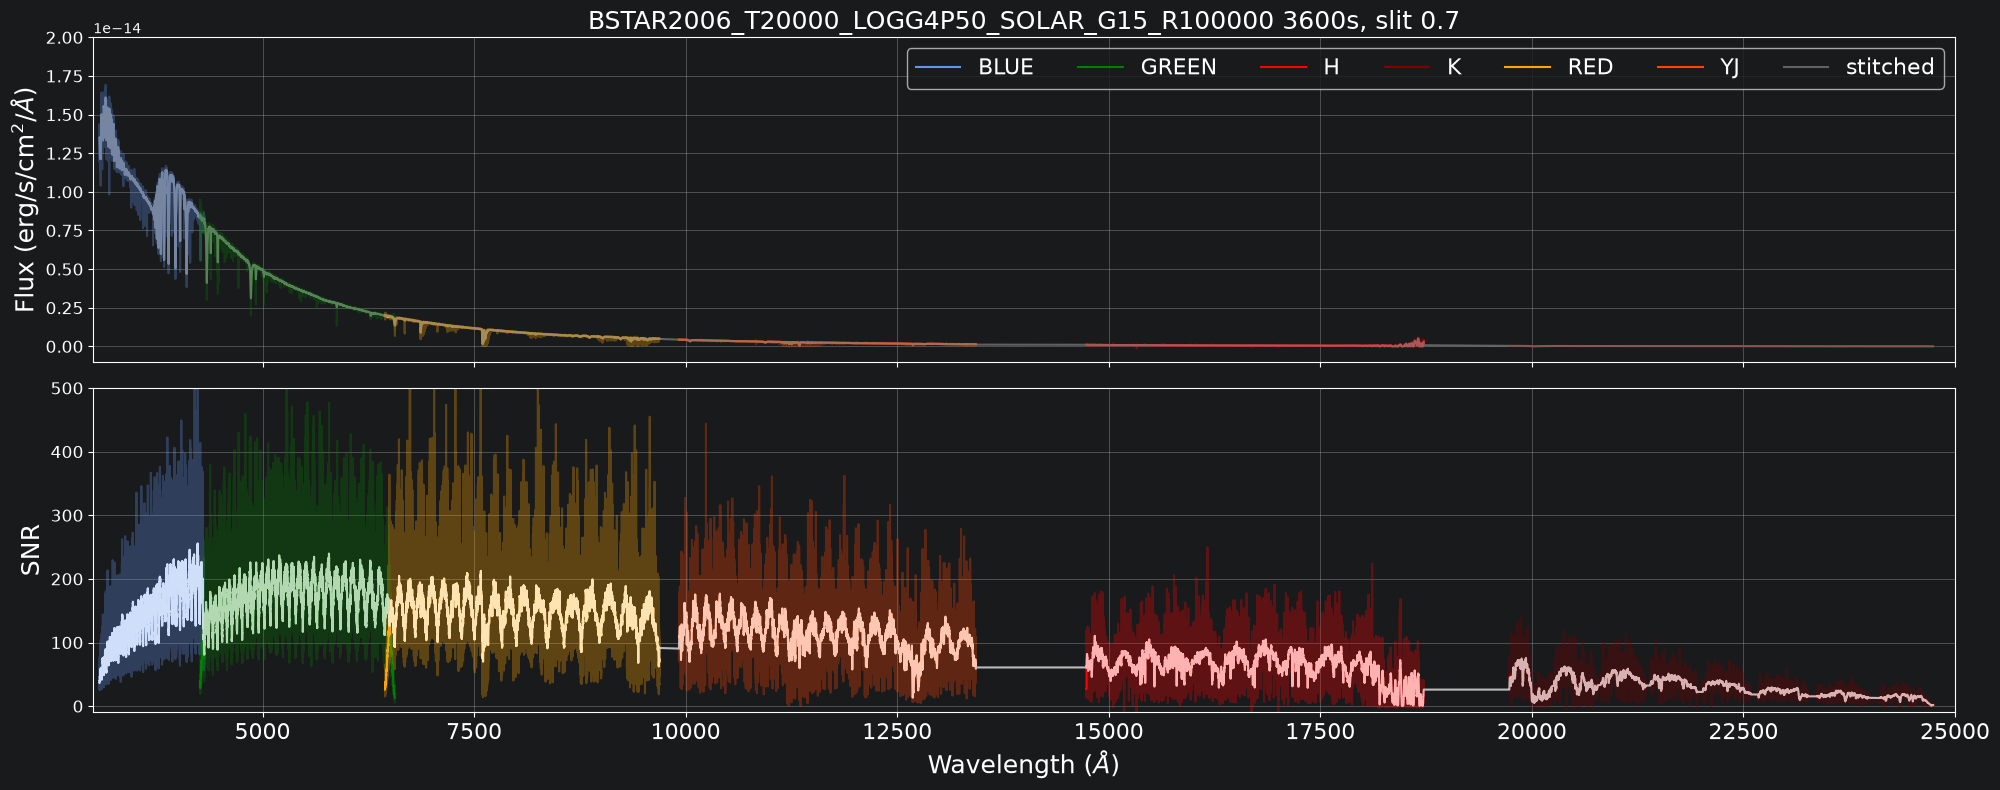

In [17]:
from astropy.table import Table
from scipy.ndimage import median_filter

obj = list(sources.keys())[0]
specfiles = sorted(REDUCED_DIR.glob(f'*{obj.upper()}_1800_SUB_*_fluxcal.txt'))
stitched = sorted(REDUCED_DIR.glob(f'*{obj.upper()}_1800_SUB*stitched.txt'))[0]

fig, ax = plt.subplots(2,1, figsize=(20,8), tight_layout=True, sharex=True)
ax[0].grid(True)
ax[1].grid(True)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='x', labelsize=16)
ax[0].set_ylabel('Flux (erg/s/cm$^2/\AA$)', fontsize=18)
ax[1].set_ylabel('SNR', fontsize=18)
ax[1].set_xlabel('Wavelength ($\AA$)', fontsize=18)
ax[0].set_title(f"{obj.upper()} 3600s, slit {vis_slit}", fontsize=18)

colors = {'BLUE': 'cornflowerblue', 'GREEN': 'green', 'RED': 'orange', 'YJ': 'orangered', 'H': 'red', 'K': 'maroon'}
for fl in specfiles:
    chan = str(fl).split('/')[-1].split('_')[-2].upper()
    tbl = Table.read(str(fl), format='ascii', delimiter='\t')
    snr = tbl['flux']/tbl['eflux']
    ax[0].plot(tbl['wavelength'], tbl['flux'], color=colors[chan], alpha=0.3)
    ax[0].plot(tbl['wavelength'], median_filter(tbl['flux'], 51), label=chan, color=colors[chan])
    ax[1].plot(tbl['wavelength'], snr, alpha=0.3, color=colors[chan])
    ax[1].plot(tbl['wavelength'], median_filter(snr, 51), color=colors[chan])
stbl = Table.read(str(stitched), format='ascii', delimiter='\t')
ax[0].plot(stbl['wavelength'], median_filter(stbl['flux'], 51), color='gray', alpha=0.7, label='stitched')
ax[1].plot(stbl['wavelength'], median_filter(stbl['flux']/stbl['eflux'], 51), color='white', alpha=0.7)

ax[0].set_xlim(3000, 25000)
ax[0].set_ylim(-0.1e-14, 2e-14)
ax[1].set_ylim(-10, 500)
ax[0].legend(ncol=7, fontsize=16)
plt.show()